# PMF, CDF, Joint Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* ...

*SID:* ...

The objective of this notebook is to understand the concepts of PMF and CDF and joint distribution.

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [2]:
num_counters = 1
arrival_rate = 5  # customers per minute
service_rate = 6  # customers per minute
simulation_time = 10000  # minutes
np.random.default_rng(seed = 467)

Generator(PCG64) at 0x2114A2A57E0

## Simulation

In [3]:
def simulate_queue_system():
    """
    Simulates a queue system with customers arriving at service counters, waiting for service, and being served.

    This function defines the customer behavior and the setup of the simulation environment. It initializes the simulation environment, sets up the service counters, and continuously generates customer arrivals based on specified arrival and service rates. The function runs the simulation until the specified simulation time and returns the recorded wait times, arrival times, and service times of the customers.

    Returns:
        tuple: A tuple containing three lists - wait_times, arrival_times, and service_times, which record the respective times for each customer in the simulation.
    """

    def customer(
        env: simpy.Environment,
        name: str,
        counter: simpy.Resource,
        service_time: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Simulates a customer arriving at a service counter, waiting for service, and then being served.

        Args:
            env (simpy.Environment): The simulation environment.
            name (str): The name of the customer.
            counter (simpy.Resource): The service counter resource.
            service_time (float): The time it takes to serve the customer.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Process: The process of the customer being served.
        """
        arrival_time = env.now
        arrival_times.append(arrival_time)
        with counter.request() as req:
            yield req
            yield env.timeout(service_time)
            service_times.append(service_time)
            wait_time = env.now - arrival_time
            wait_times.append(wait_time)

    def setup(
        env: simpy.Environment,
        num_counters: int,
        arrival_rate: float,
        service_rate: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Sets up the simulation environment with a specified number of service counters and customer arrival and service rates.

        Args:
            env (simpy.Environment): The simulation environment.
            num_counters (int): The number of service counters available.
            arrival_rate (float): The rate at which customers arrive.
            service_rate (float): The rate at which customers are served.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.
            
        Yields:
            simpy.events.Timeout: The timeout event for the next customer arrival.
        """
        counter = simpy.Resource(env, num_counters)
        while True:
            yield env.timeout(np.random.exponential(1 / arrival_rate))
            service_time = np.random.exponential(1 / service_rate)
            env.process(
                customer(
                    env,
                    "Customer",
                    counter,
                    service_time,
                    wait_times,
                    arrival_times,
                    service_times,
                )
            )

    while True:
        env = simpy.Environment()
        wait_times = []
        arrival_times = []
        service_times = []
        env.process(
            setup(
                env,
                num_counters,
                arrival_rate,
                service_rate,
                wait_times,
                arrival_times,
                service_times,
            )
        )
        env.run(until=simulation_time)

        if len(wait_times) == len(arrival_times) == len(service_times):
            return wait_times, arrival_times, service_times
        
wait_times, arrival_times, service_times = simulate_queue_system()

## Plot the RVs Distributions

In this part I will plot the three distributions we've generated on three histograms. 

Kernel Density Estimation (KDE) parameter shows the estimation of distribution on the current X axis. This means it is a smooth line which helps us to visualize and analyze the trends in our data. It is something like indicators in the stock charts in financial markets :)

Actually KDE is an estimation for the Probability Density Function(PDF) according to the limited number of data we have.

I tried to change the color of kde in my plot but I couldn't. So I changed the transparency of the lines and increased the thickness of the kde lines.

Also we can see that if we change the value of the kde argument to False, it won't plot the kde line. You can have this indicator on your histograms by putting the kde parameter equal to True.

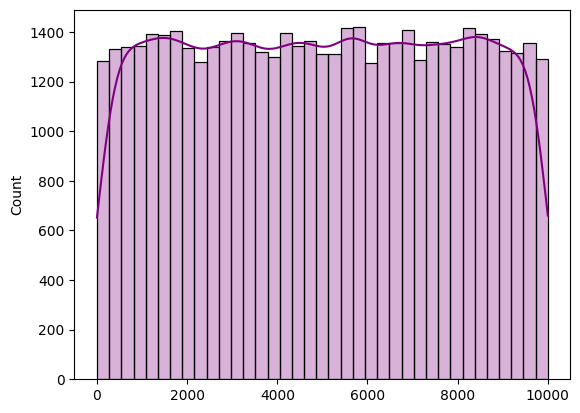

<Axes: ylabel='Count'>

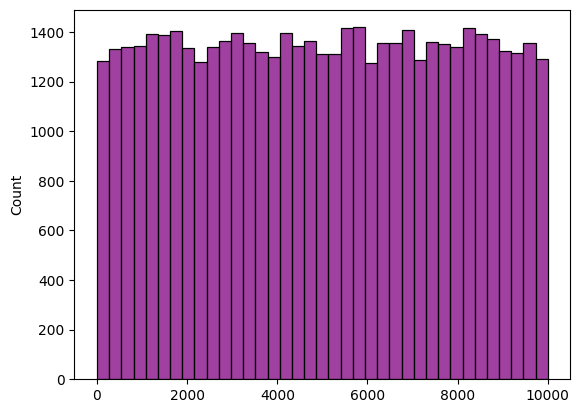

In [4]:
######################  TODO  ########################
sns.histplot(data = arrival_times, color = "purple", kde = True, alpha = 0.3)
plt.show()

#without kde:
sns.histplot(data = arrival_times, color = "purple", kde = False)
######################  TODO  ########################

<Axes: ylabel='Count'>

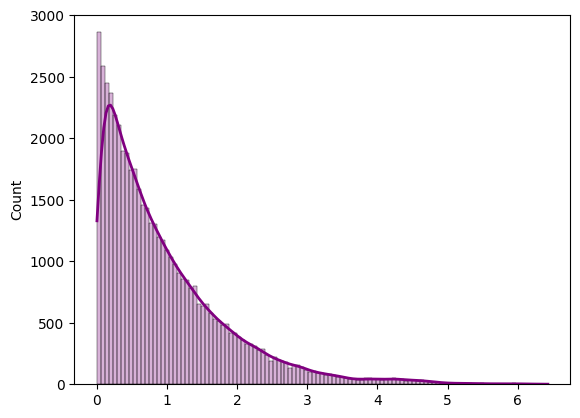

In [5]:
######################  TODO  ########################
sns.histplot(data = wait_times, color = "purple", kde = True, line_kws={'lw': 2}, alpha = 0.3)
######################  TODO  ########################

<Axes: ylabel='Count'>

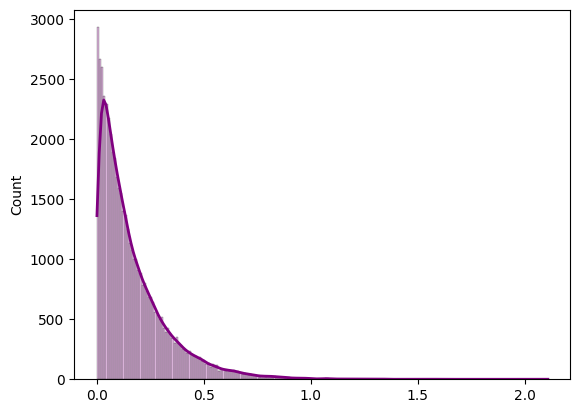

In [6]:
######################  TODO  ########################
sns.histplot(data = service_times, color = "purple", kde = True, line_kws={'lw': 2}, alpha = 0.3)
######################  TODO  ########################

## Plot the Joint Distributions

**Note:** Use `sns.jointplot` to plot the joint distributions

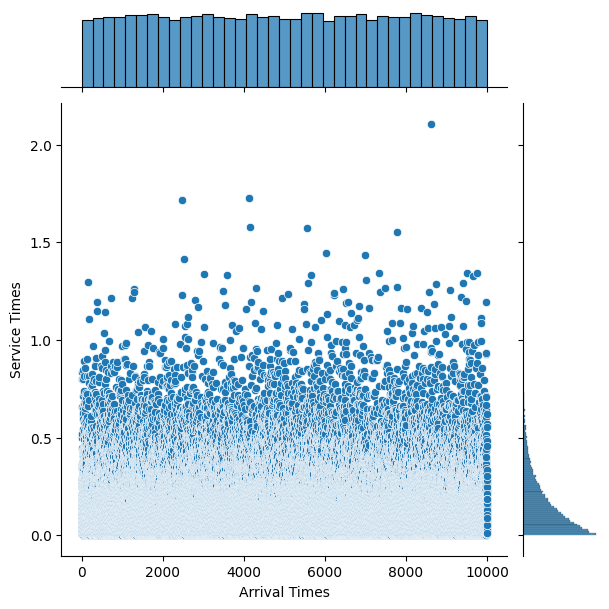

In [7]:
######################  TODO  ########################
sns.jointplot(x = arrival_times, y = service_times)
plt.xlabel("Arrival Times")
plt.ylabel("Service Times")
plt.show()
######################  TODO  ########################

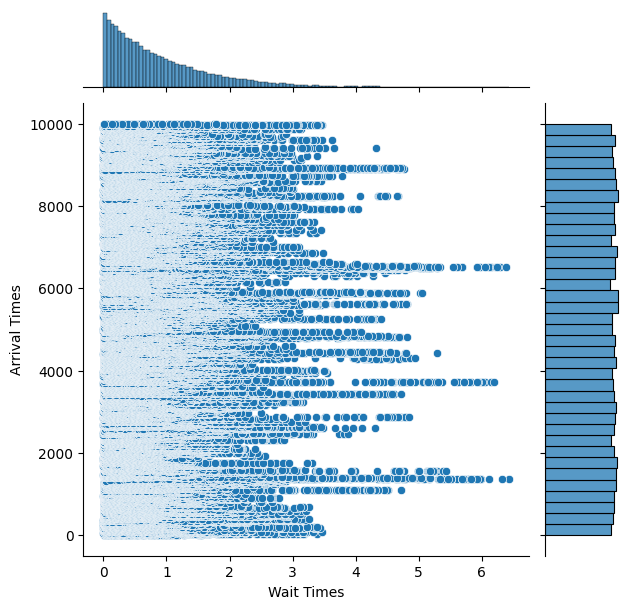

In [8]:
######################  TODO  ########################
sns.jointplot(x = wait_times, y = arrival_times)
plt.xlabel("Wait Times")
plt.ylabel("Arrival Times")
plt.show()
######################  TODO  ########################

## Analysis of Joint Distributions
As we can see, the density of points is much more on the bottom of the plot. It's because the service time obeys the exponential distribution and it's much more probable to be arround 0. 


It's obvious that we can not fit a line on this data appropriately and the variables are absoulutely not linearly dependent at all. This proves that the correlation coefficient for this data is too low(arround 0.) 

## Scatter Plot and Correlation

-0.0009674242043743392
-0.0009674242043743502


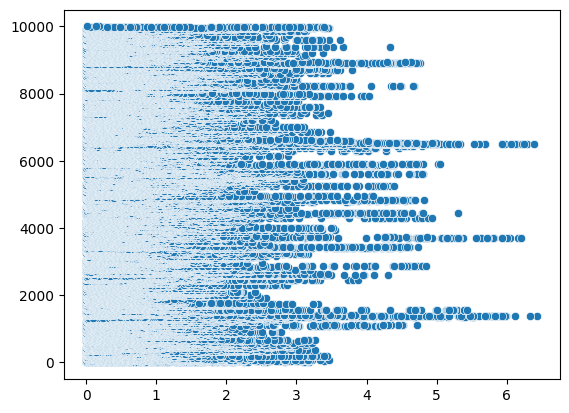

In [13]:
######################  TODO  ########################
sns.scatterplot(x = wait_times, y = arrival_times)

size = len(wait_times)
wait_times_normalized = (wait_times - np.average(wait_times)) / np.std(wait_times)
arrival_times_normalized = (arrival_times - np.average(arrival_times)) / np.std(arrival_times)
correlation_coefficient = np.dot(wait_times_normalized, arrival_times_normalized) / size
print(correlation_coefficient)

correlation_coefficient_using_method = np.corrcoef(wait_times, arrival_times)[0][1]
print(correlation_coefficient_using_method)
######################  TODO  ########################

I both calculated the correlation coefficent using and without using np.corrcoef() function and they were equal(with a very slight difference.)

## Calculating `total_times`

This list shows the times that each customer has left. To determine the distribution I have to plot the times and distinguish the distribution by that.

<Axes: ylabel='Count'>

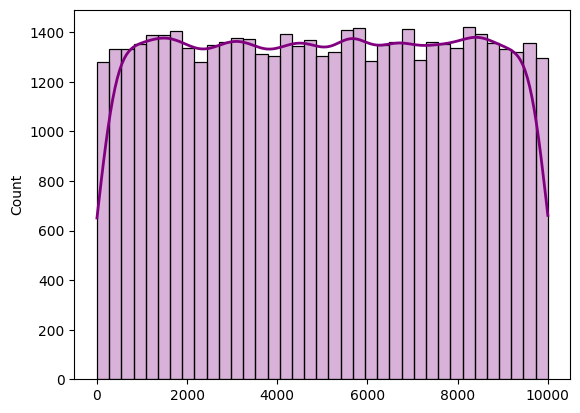

In [20]:
######################  TODO  ########################
total_times = [0] * len(arrival_times)
for i in range(len(total_times)):
    total_times[i] = arrival_times[i] + wait_times[i] + service_times[i]
    
sns.histplot(data = total_times, color = "purple", kde = True, line_kws={'lw': 2}, alpha = 0.3)
######################  TODO  ########################

According to the shape, the total time random variable distribution is uniform. This means that the time which a customer leaves the office follows a uniform distribution and has equal probabilities for each time in the period.

## Conditional Wait Times

<Axes: ylabel='Count'>

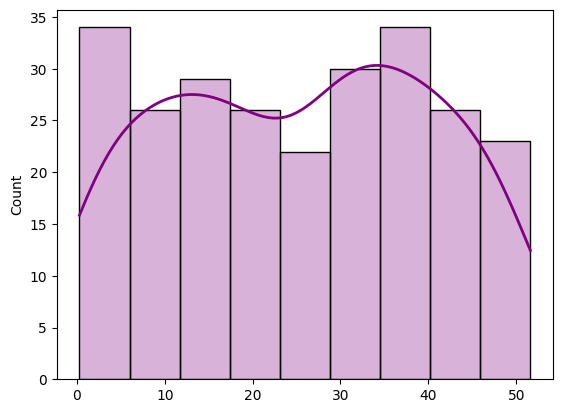

In [21]:
######################  TODO  ########################
total_times_conditional = []

for i in range(len(total_times)):
    if arrival_times[i] < 50:
        total_times_conditional.append(arrival_times[i] + wait_times[i] + service_times[i])
        
sns.histplot(data = total_times_conditional, color = "purple", kde = True, line_kws={'lw': 2}, alpha = 0.3)
######################  TODO  ########################

According to the shape, this conditional distribution is uniform too.